# Análisis exploratorio: frecuencia de palabras

Gráficos de las palabras y bigramas más frecuentes (globales y por categoría) y comparación
de las palabras que aparecen en ambas clases. Se trabaja sobre `text_final` de
`train_clean.csv` (texto limpio, sin stopwords y lematizado).

El resto del análisis exploratorio (dimensiones, faltantes, balance de clases, longitud de
los tweets, `keyword` y `location`, duplicados) está en `notebooks/01_descripcion_datos.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer

plt.rcParams["figure.dpi"] = 110
OUT = Path("../output"); OUT.mkdir(exist_ok=True)

df = pd.read_csv("../data/train_clean.csv")
df["text_final"] = df["text_final"].fillna("")
print("Filas:", len(df))
df["target"].value_counts()


Filas: 7484


target
0    4297
1    3187
Name: count, dtype: int64

## 1. Frecuencia de palabras

In [2]:
def frecuencias(textos, ngram_range=(1, 1), min_df=2):
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vec.fit_transform(textos)
    freq = np.asarray(X.sum(axis=0)).ravel()
    return (pd.Series(freq, index=vec.get_feature_names_out())
            .sort_values(ascending=False))

freq_global = frecuencias(df["text_final"])
freq_global.head(20)


not          748
fire         349
like         345
get          255
new          226
via          217
one          209
news         195
people       193
would        188
video        169
time         161
emergency    158
year         157
disaster     156
body         152
day          147
police       140
home         138
say          131
dtype: int64

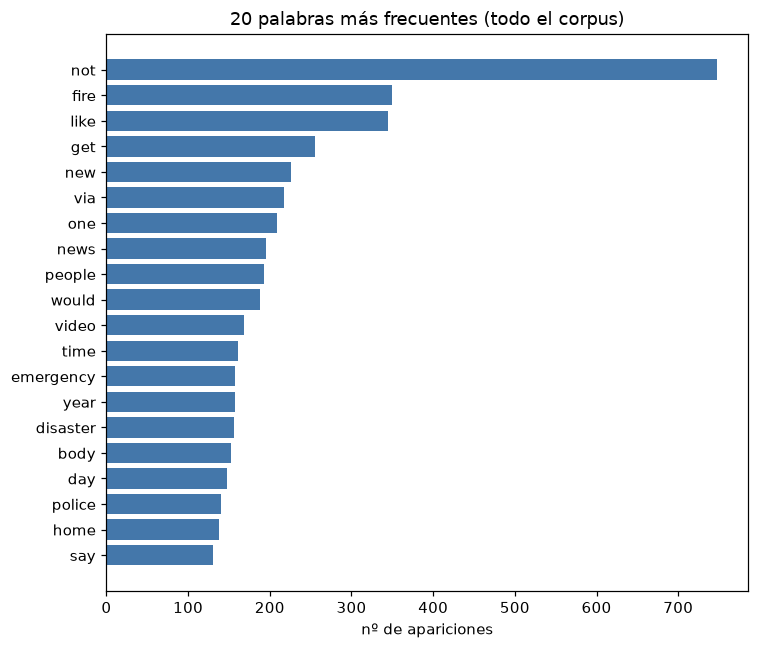

In [3]:
top = freq_global.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color="#4477aa")
ax.set_xlabel("nº de apariciones")
ax.set_title("20 palabras más frecuentes (todo el corpus)")
plt.tight_layout(); plt.savefig(OUT / "top_palabras_global.png"); plt.show()


## 2. Palabras más frecuentes por categoría

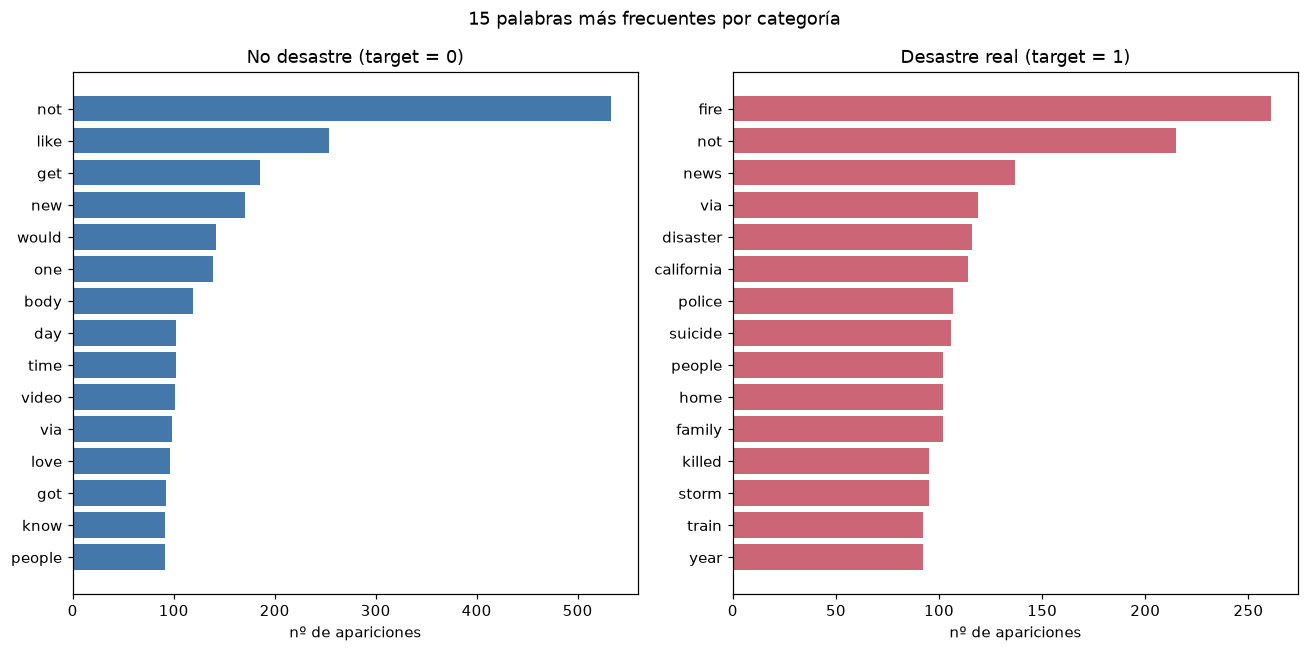

In [4]:
freq_0 = frecuencias(df.loc[df.target == 0, "text_final"]).head(15).iloc[::-1]
freq_1 = frecuencias(df.loc[df.target == 1, "text_final"]).head(15).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].barh(freq_0.index, freq_0.values, color="#4477aa")
axes[0].set_title("No desastre (target = 0)")
axes[1].barh(freq_1.index, freq_1.values, color="#cc6677")
axes[1].set_title("Desastre real (target = 1)")
for ax in axes:
    ax.set_xlabel("nº de apariciones")
fig.suptitle("15 palabras más frecuentes por categoría")
plt.tight_layout(); plt.savefig(OUT / "top_palabras_por_clase.png"); plt.show()


In [5]:
pd.DataFrame({
    "no_desastre": frecuencias(df.loc[df.target == 0, "text_final"]).head(15).index,
    "desastre":    frecuencias(df.loc[df.target == 1, "text_final"]).head(15).index,
})


,no_desastre,desastre
0,not,fire
1,like,not
2,get,news
3,new,via
4,would,disaster
5,one,california
6,body,police
7,day,suicide
8,time,people
9,video,home


## 3. Bigramas más frecuentes por categoría

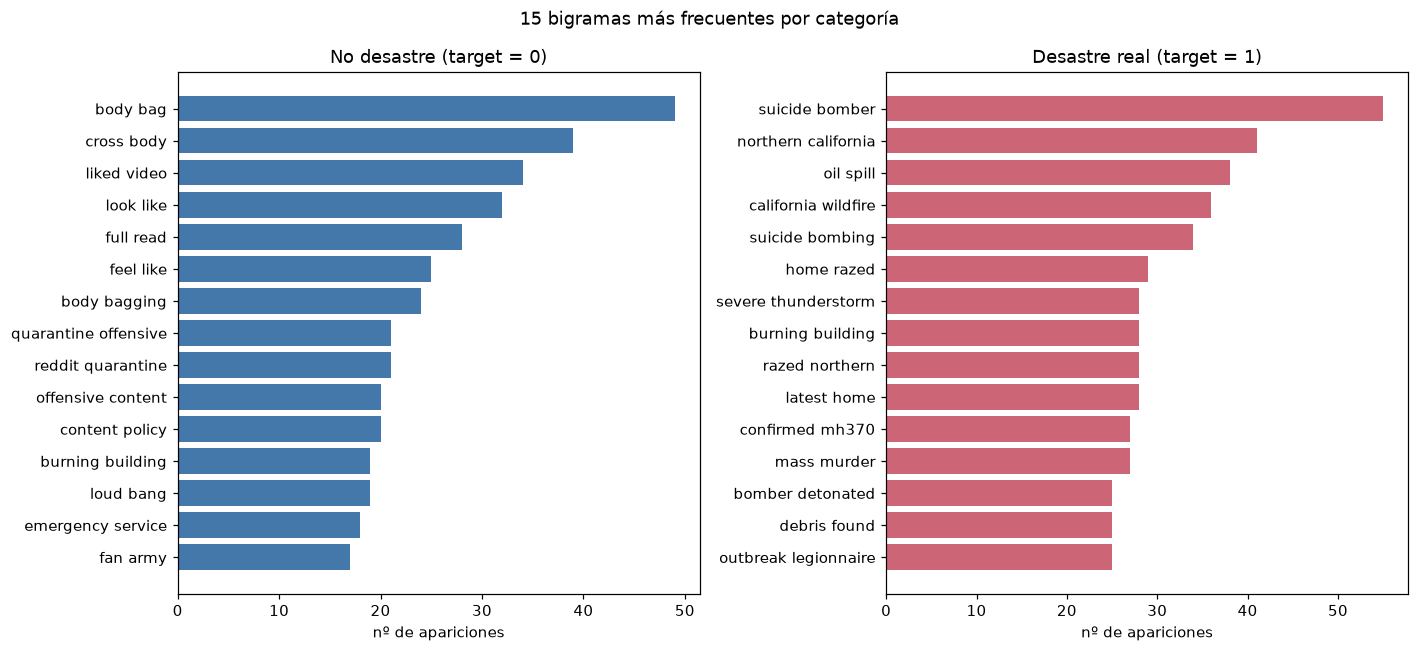

In [6]:
bi_0 = frecuencias(df.loc[df.target == 0, "text_final"], (2, 2)).head(15).iloc[::-1]
bi_1 = frecuencias(df.loc[df.target == 1, "text_final"], (2, 2)).head(15).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(bi_0.index, bi_0.values, color="#4477aa")
axes[0].set_title("No desastre (target = 0)")
axes[1].barh(bi_1.index, bi_1.values, color="#cc6677")
axes[1].set_title("Desastre real (target = 1)")
for ax in axes:
    ax.set_xlabel("nº de apariciones")
fig.suptitle("15 bigramas más frecuentes por categoría")
plt.tight_layout(); plt.savefig(OUT / "top_bigramas_por_clase.png"); plt.show()


## 4. Palabras que aparecen en las dos categorías

Se comparan las frecuencias relativas de cada palabra en las dos clases. Las palabras cerca
de la diagonal aparecen por igual en ambas (poco informativas); las que se alejan de la
diagonal son propias de una clase (útiles para clasificar).

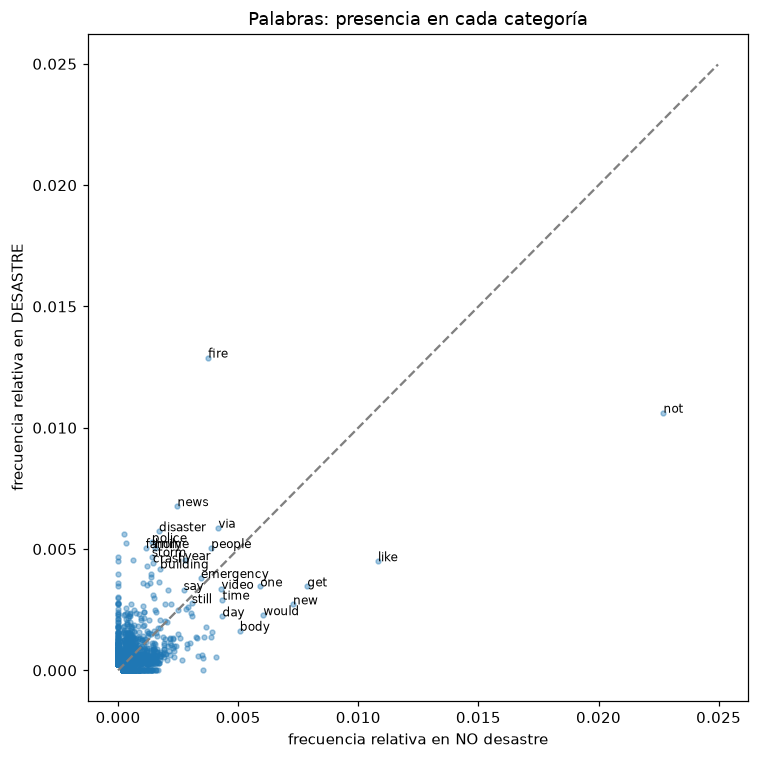

In [7]:
f0 = frecuencias(df.loc[df.target == 0, "text_final"], min_df=5)
f1 = frecuencias(df.loc[df.target == 1, "text_final"], min_df=5)

comp = pd.DataFrame({"n_no_desastre": f0, "n_desastre": f1}).fillna(0)
comp["rel_no_desastre"] = comp["n_no_desastre"] / comp["n_no_desastre"].sum()
comp["rel_desastre"]    = comp["n_desastre"]    / comp["n_desastre"].sum()
comp["total"] = comp["n_no_desastre"] + comp["n_desastre"]
comp["log_ratio"] = np.log2((comp["rel_desastre"] + 1e-6) / (comp["rel_no_desastre"] + 1e-6))

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(comp["rel_no_desastre"], comp["rel_desastre"], s=10, alpha=0.4)
lim = max(comp["rel_no_desastre"].max(), comp["rel_desastre"].max()) * 1.1
ax.plot([0, lim], [0, lim], "--", color="grey")
for w in comp.sort_values("total", ascending=False).head(25).index:
    ax.annotate(w, (comp.loc[w, "rel_no_desastre"], comp.loc[w, "rel_desastre"]), fontsize=8)
ax.set_xlabel("frecuencia relativa en NO desastre")
ax.set_ylabel("frecuencia relativa en DESASTRE")
ax.set_title("Palabras: presencia en cada categoría")
plt.tight_layout(); plt.savefig(OUT / "palabras_comunes.png"); plt.show()


In [8]:
# Palabras frecuentes MÁS repartidas entre las dos clases (|log_ratio| pequeño)
comunes = (comp[comp["total"] >= 60]
           .assign(abs_lr=comp["log_ratio"].abs())
           .sort_values("abs_lr")
           .head(20)[["n_no_desastre", "n_desastre", "log_ratio"]])
print("Palabras frecuentes presentes por igual en ambas categorías:")
comunes


Palabras frecuentes presentes por igual en ambas categorías:


,n_no_desastre,n_desastre,log_ratio
plan,41.0,35.0,-0.014924
first,59.0,50.0,-0.025441
school,37.0,31.0,-0.041894
weapon,46.0,41.0,0.047302
could,48.0,40.0,-0.049674
fatality,39.0,35.0,0.057183
live,32.0,30.0,0.120142
another,35.0,33.0,0.128365
emergency,81.0,77.0,0.140234
life,68.0,53.0,-0.146153


In [9]:
# Palabras más distintivas de cada clase
print("Más propias de DESASTRE (log_ratio alto):")
print(comp[comp.total >= 30].sort_values("log_ratio", ascending=False).head(15)[["n_no_desastre", "n_desastre", "log_ratio"]])
print("\nMás propias de NO DESASTRE (log_ratio bajo):")
print(comp[comp.total >= 30].sort_values("log_ratio").head(15)[["n_no_desastre", "n_desastre", "log_ratio"]])


Más propias de DESASTRE (log_ratio alto):
             n_no_desastre  n_desastre  log_ratio
killed                 0.0        95.0  12.196169
hiroshima              0.0        91.0  12.134121
wildfire               0.0        80.0  11.948299
bombing                0.0        73.0  11.816230
mh370                  0.0        70.0  11.755706
northern               0.0        61.0  11.557222
legionnaire            0.0        60.0  11.533383
bomber                 0.0        56.0  11.433882
typhoon                0.0        56.0  11.433882
japan                  0.0        55.0  11.407896
atomic                 0.0        55.0  11.407896
warning                0.0        51.0  11.299004
debris                 0.0        49.0  11.241311
severe                 0.0        47.0  11.181216
malaysia               0.0        47.0  11.181216

Más propias de NO DESASTRE (log_ratio bajo):
             n_no_desastre  n_desastre  log_ratio
bag                   83.0         0.0 -11.788117
ruin        